# 00 — Reference parity and Gate 1.0

*Confirmed results C1–C10. Every number is recomputed, not quoted.*

Companion to `bitacora/01_reference_parity.md` and `bitacora/02_gate10.md`.

In [1]:
"""Path setup: makes the notebook runnable from anywhere."""
import os, sys, json, warnings
warnings.filterwarnings("ignore")

here = os.path.abspath(os.getcwd())
while here != "/" and not os.path.exists(os.path.join(here, "PROTOCOL_causal_timeseries.md")):
    here = os.path.dirname(here)
if here == "/":
    here = os.path.expanduser("~/Documents/projects/CausalBool/imp-prices")
ROOT = here
sys.path.insert(0, os.path.join(ROOT, "src"))
sys.path.insert(0, os.path.join(ROOT, "scripts"))

import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})
print("root:", ROOT)
print("numpy", np.__version__, "| pandas", pd.__version__, "| matplotlib", matplotlib.__version__)

root: /Users/alberto/Documents/projects/CausalBool/imp-prices
numpy 2.2.6 | pandas 2.3.3 | matplotlib 3.11.1


## 1. What this notebook establishes

Two things, both frozen in the ledger:

1. **Reference parity (C1–C4).** Our port of the GWP3 pipeline agrees with its
   recorded output on 3,124 independent numbers. Until that holds, no comparison
   in this package measures the method rather than the port.
2. **Gate 1.0 (C5–C10).** The pre-registered feasibility test. There *is*
   deterministic structure in the discretised panel, and it is **persistence**.
   Nothing else adds to it.

Every number printed below is recomputed here, not quoted.

### 2. The panel and its chronological allocation (anchors A1–A3)

In [2]:
from imp_prices import load_and_split, split_summary, SERIES, TARGET
from imp_prices.config import GWP3_RESULTS

split = load_and_split()
reference = json.load(open(GWP3_RESULTS))

print("panel:", split.full.shape, "|", split.full.index[0].date(), "to", split.full.index[-1].date())
print("split sizes (train/val/test):", split.sizes)
summary = split_summary(split)
display(summary)
print("\nidentical to the GWP3 record:", summary.to_dict("records") == reference["split"])

panel: (199, 7) | 2010-01-31 to 2026-07-31
split sizes (train/val/test): (139, 30, 30)


,Set,Months,Start,End,Share,Mean_price,Mean_logret,Vol_logret,Min_price,Max_price
0,Training,139,2010-01-31,2021-07-31,69.8,69.34,0.0001,0.1231,19.23,113.39
1,Validation,30,2021-08-31,2024-01-31,15.1,83.61,0.0037,0.0950,66.14,114.38
2,Testing,30,2024-02-29,2026-07-31,15.1,73.39,-0.0000,0.1196,57.26,108.64



identical to the GWP3 record: True


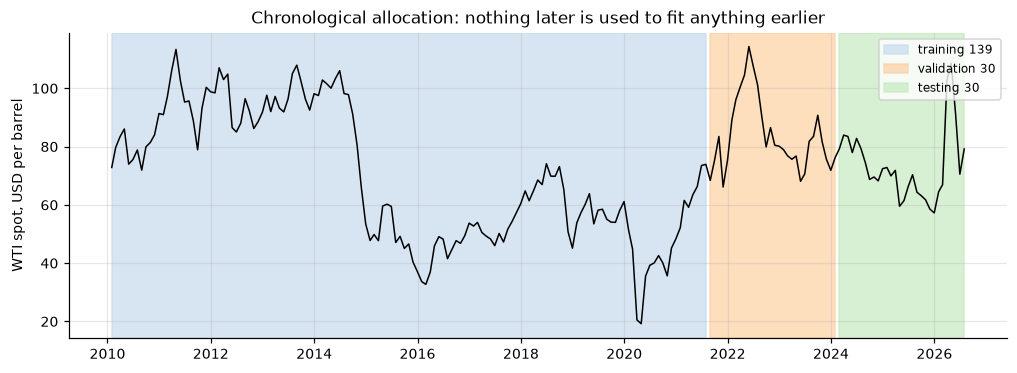

In [3]:
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(split.full.index, split.full[TARGET], color="black", lw=1.0)
for part, colour, name in [(split.train, "#C6DBEF", "training 139"),
                           (split.val, "#FDD0A2", "validation 30"),
                           (split.test, "#C7E9C0", "testing 30")]:
    ax.axvspan(part.index[0], part.index[-1], color=colour, alpha=0.7, label=name)
ax.set_ylabel("WTI spot, USD per barrel"); ax.legend(loc="upper right", fontsize=8)
ax.set_title("Chronological allocation: nothing later is used to fit anything earlier")
plt.show()

### 3. The discretisation, and why it is the whole study

GWP3 conclusion 2: *discretisation matters more than model choice*. The two
emission schemes are fitted below and the difference is not subtle.

In [4]:
from imp_prices import RegimeDiscretiser, regime_economics

disc, frames = {}, {}
for kind in ("parity", "gaussian"):
    disc[kind] = RegimeDiscretiser(kind).fit(split.train)
    frames[kind] = disc[kind].transform(split.full)

rows = []
for kind in ("parity", "gaussian"):
    p = disc[kind].params[TARGET]
    col = frames[kind][TARGET].values
    rows.append(dict(scheme=kind, log_likelihood=p["log_likelihood"],
                     mean_diagonal=p["persistence"],
                     switches=int((np.diff(col) != 0).sum()),
                     months=len(col)))
display(pd.DataFrame(rows))
print("A4: parity persistence is exactly zero ->", disc["parity"].params[TARGET]["persistence"] == 0.0)
print("A5: log-return persistence 0.742      ->", disc["gaussian"].params[TARGET]["persistence"])

Model is not converging.  Current: 133.6292135815284 is not greater than 133.64611090460522. Delta is -0.016897323076818793


Model is not converging.  Current: 135.12412379396633 is not greater than 135.13466135759776. Delta is -0.010537563631430658


Model is not converging.  Current: 137.95241214051376 is not greater than 137.9719991672316. Delta is -0.019587026717829303


Model is not converging.  Current: 133.8785930254865 is not greater than 133.88411470889034. Delta is -0.0055216834038276374


Model is not converging.  Current: 137.8805787609427 is not greater than 137.88701219673231. Delta is -0.0064334357896029815


...

Model is not converging.  Current: 138.689566784798 is not greater than 138.75651219277114. Delta is -0.06694540797315085


Model is not converging.  Current: 137.73058048980627 is not greater than 137.74346014343874. Delta is -0.012879653632467125


Model is not converging.  Current: 137.0533835102066 is not greater than 137.05519354805233. Delta is -0.0018100378457290844


,scheme,log_likelihood,mean_diagonal,switches,months
0,parity,-92.367,0.0000,189,198
1,gaussian,138.526,0.7421,52,198


A4: parity persistence is exactly zero -> True
A5: log-return persistence 0.742      -> 0.7421


In [5]:
# Every fitted parameter of all seven models, both schemes, against the record.
def count_scalars(o):
    if isinstance(o, dict):  return sum(count_scalars(v) for v in o.values())
    if isinstance(o, list):  return sum(count_scalars(v) for v in o)
    return 1

checked = 0
for kind in ("parity", "gaussian"):
    ours, theirs = disc[kind].params, reference[f"hmm_{kind}"]
    for s in SERIES:
        for key, val in ours[s].items():
            ref = theirs[s][key]
            if key == "state_means_raw":
                assert {str(k): v for k, v in val.items()} == ref, (kind, s, key)
            elif isinstance(val, float):
                assert abs(val - ref) < 1e-3, (kind, s, key)
            else:
                np.testing.assert_allclose(np.asarray(val, float), np.asarray(ref, float), atol=1e-4)
        checked += count_scalars(ours[s])

cells = 0
for kind in ("parity", "gaussian"):
    for name, part in [("train", split.train), ("validation", split.val), ("test", split.test)]:
        ref = pd.read_csv(os.path.join(ROOT, "reference", "gwp3", f"discrete_{kind}_{name}.csv"),
                          parse_dates=["Date"], index_col="Date")[SERIES].astype(int)
        ours = frames[kind].reindex(part.index).dropna().astype(int)
        pd.testing.assert_frame_equal(ours, ref, check_dtype=False)
        cells += ours.size

print(f"fitted parameters verified : {checked}")
print(f"decoded regime labels      : {cells}")
print(f"split summary fields       : 30")
print(f"TOTAL (ledger C1)          : {checked + cells + 30}")

fitted parameters verified : 322
decoded regime labels      : 2772
split summary fields       : 30
TOTAL (ledger C1)          : 3124


#### Looking at the regimes, not only asserting them

The numerical parity above is the evidence. The figure below is the *reason* the
log-return scheme is the one carried forward: a regime that lasts a single month
is not a regime, and a system that reports a fresh market state every month
cannot inform a position held for a quarter.

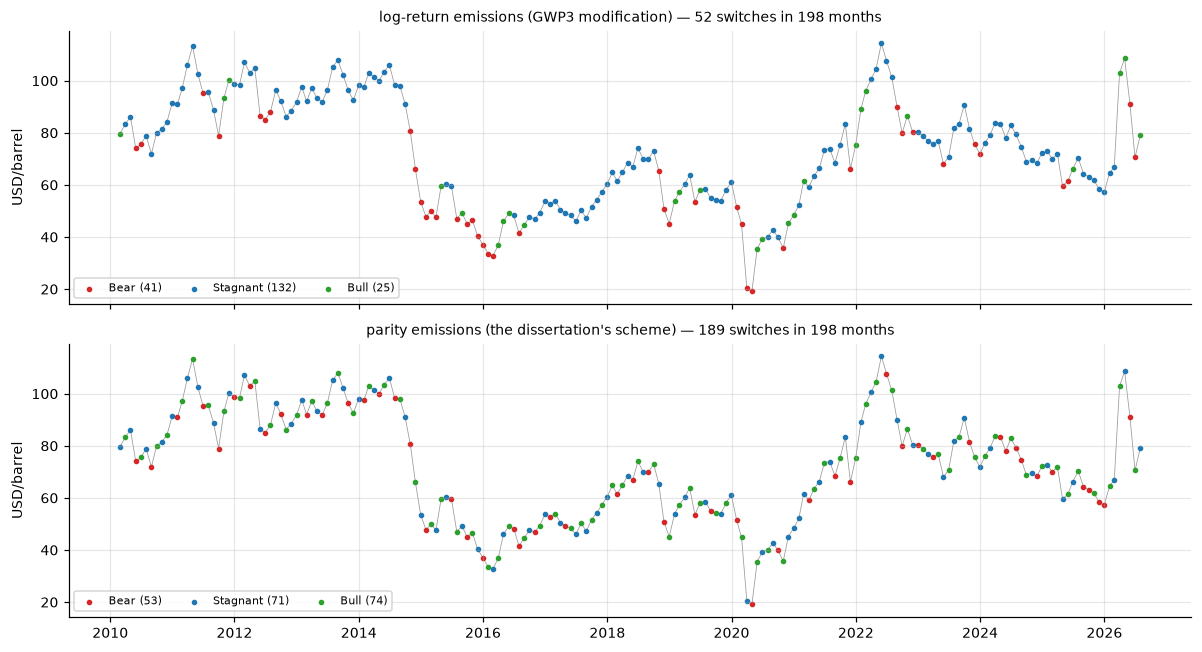

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
colours = np.array(["#D62728", "#1F77B4", "#2CA02C"])
labels = ["Bear", "Stagnant", "Bull"]
for ax, kind, title in [(axes[0], "gaussian", "log-return emissions (GWP3 modification)"),
                        (axes[1], "parity", "parity emissions (the dissertation's scheme)")]:
    px = split.full[TARGET].iloc[1:]
    reg = frames[kind][TARGET].values
    for k in range(3):
        m = reg == k
        ax.scatter(px.index[m], px.values[m], s=7, color=colours[k], label=f"{labels[k]} ({m.sum()})")
    ax.plot(px.index, px.values, color="0.6", lw=0.5, zorder=0)
    sw = int((np.diff(reg) != 0).sum())
    ax.set_title(f"{title} — {sw} switches in {len(reg)} months", fontsize=9)
    ax.legend(fontsize=7, ncol=3); ax.set_ylabel("USD/barrel")
plt.tight_layout(); plt.show()

In [7]:
train_reg = frames["gaussian"].reindex(split.train.index).dropna()[TARGET].astype(int)
econ = regime_economics(split.full[TARGET], train_reg)
display(econ)
print("A6 reproduced (Table 9): means increase with the state index ->",
      bool((econ["Mean_log_return"].diff().dropna() > 0).all()))

,State,Months,Mean_log_return,Volatility,Share
0,0,30,-0.1289,0.1463,21.7
1,1,91,0.0143,0.0532,65.9
2,2,17,0.1518,0.1350,12.3


A6 reproduced (Table 9): means increase with the state index -> True


### 4. Strict causality, and the control on the control (C3, C4)

Rule R1: no quantity used to predict month *t+1* may depend on any observation
after *t*. Decoding is filtered, never smoothed.

The check is truncation invariance — removing the future must not change any
earlier label. The first version of this check used a single cut and **passed a
decoder that leaks**: at month 120 a whole-window Viterbi changed only 1 of 833
labels. The check now sweeps five cuts, and the leaky decoder is a permanent
positive control.

In [8]:
d = disc["gaussian"]
full = d.transform(split.full)

def smoothed(df):
    out = {}
    for s in SERIES:
        x, _ = d._emit(df[s], d.clip[s])
        _, seq = d.models[s].decode(x, algorithm="viterbi")
        out[s] = [d.relabel[s][int(k)] for k in seq]
    return np.asarray([out[s] for s in SERIES]).T

sm_full = smoothed(split.full)
rows = []
for cut in (60, 90, 120, 150, 180):
    filt = d.transform(split.full.iloc[:cut])
    n_f = int((full.loc[filt.index].values != filt.values).sum())
    sm = smoothed(split.full.iloc[:cut])
    n_s = int((sm_full[:len(sm)] != sm).sum())
    rows.append(dict(cut=cut, labels=sm.size, filtered_changed=n_f, smoothed_changed=n_s))
display(pd.DataFrame(rows))
print("filtered decoder never changes an earlier label; the leaky one does.")
print("at cut=120 alone the leaky decoder changes 1 of 833 -> a one-point test would have passed it.")

,cut,labels,filtered_changed,smoothed_changed
0,60,413,0,0
1,90,623,0,0
2,120,833,0,1
3,150,1043,0,5
4,180,1253,0,0


filtered decoder never changes an earlier label; the leaky one does.
at cut=120 alone the leaky decoder changes 1 of 833 -> a one-point test would have passed it.


### 5. Gate 1.0 — coverage first, because it conditions everything (C7)

Seven ternary variables give a 2,187-state input space. The training window
supplies 138 observations. A contradiction rate measured on the *full* pattern
would be near zero because almost nothing recurs — that is absence of data, not
evidence of determinism.

,n_observations,state_space,distinct_states,coverage,recurring_states,max_multiplicity,observations_in_recurring
0,138,2187,34,0.015546,15,44,119


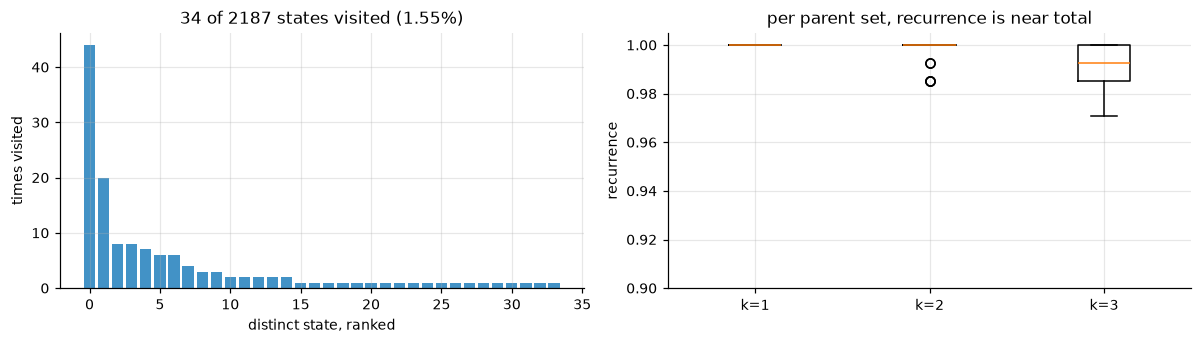

whole-pattern statistics are uninterpretable; per-parent-set statistics are not.
that difference IS the factorisation the index-set method relies on.


In [9]:
from imp_prices.feasibility import coverage, scan, pattern_stats, build_design

train = frames["gaussian"].reindex(split.train.index).dropna().astype(int)
cov = coverage(train, SERIES)
display(pd.DataFrame([cov]))

X = train[SERIES].to_numpy(np.int64)
codes = np.zeros(len(X), np.int64)
for j in range(X.shape[1]):
    codes = codes * 3 + X[:, j]
_, mult = np.unique(codes, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].bar(range(len(mult)), sorted(mult, reverse=True), color="#4292C6")
axes[0].set_xlabel("distinct state, ranked"); axes[0].set_ylabel("times visited")
axes[0].set_title(f"{cov['distinct_states']} of 2187 states visited ({100*cov['coverage']:.2f}%)")
tab = scan(train, TARGET, SERIES, 3)
axes[1].boxplot([g["recurrence"].values for _, g in tab.groupby("k")], tick_labels=["k=1","k=2","k=3"])
axes[1].set_ylabel("recurrence"); axes[1].set_ylim(0.9, 1.005)
axes[1].set_title("per parent set, recurrence is near total")
plt.tight_layout(); plt.show()
print("whole-pattern statistics are uninterpretable; per-parent-set statistics are not.")
print("that difference IS the factorisation the index-set method relies on.")

### 6. The null that had to be replaced (C6)

The pre-registered null permuted the successor column. It preserves the regime
marginal but destroys the successor's **autocorrelation** — and two persistent yet
wholly independent processes align spuriously over a finite sample. A permutation
null cannot reproduce that, so it certifies the alignment as structure.

The control is seven independent Markov chains: persistence, and nothing else.

In [10]:
from imp_prices.controls import persistent_random_frame, random_frame, rule110_frame
from imp_prices.feasibility import circular_shift_null, shuffle_null, covariate_shift_null

per = persistent_random_frame(width=7, steps=200, n_values=3, stay=0.75)
others = [c for c in per.columns if c != "c0"]

rows = [
    dict(control="persistent, CROSS only (must be null)",
         permutation_p=shuffle_null(per, "c0", others, 3, 3, 0.5, 200, 42)["p_lookup_accuracy"],
         circular_shift_p=circular_shift_null(per, "c0", others, 3)["p_lookup_accuracy"]),
    dict(control="persistent, self allowed (must be positive)",
         permutation_p=shuffle_null(per, "c0", list(per.columns), 3, 3, 0.5, 200, 42)["p_lookup_accuracy"],
         circular_shift_p=circular_shift_null(per, "c0", list(per.columns), 3)["p_lookup_accuracy"]),
]
display(pd.DataFrame(rows).set_index("control").round(4))
print("The permutation null reports structure in a system built to contain none.")
print("The circular shift rejects it, while still detecting the genuine persistence.")

,permutation_p,circular_shift_p
control,,
"persistent, CROSS only (must be null)",0.005,0.4921
"persistent, self allowed (must be positive)",0.005,0.0053


The permutation null reports structure in a system built to contain none.
The circular shift rejects it, while still detecting the genuine persistence.


#### And the positive control: a deterministic system must be recovered exactly (C5)

In [11]:
ca = rule110_frame(width=7, steps=200)
ca_tab = scan(ca, "c0", list(ca.columns), 3, n_values=2)
best = ca_tab.loc[ca_tab["contradiction"].idxmin()]
print(f"rule 110  best parents {best['parents']}  contradiction {best['contradiction']}  "
      f"lookup accuracy {best['lookup_accuracy']}")
print("exact parent sets at in-degree 3:", int((ca_tab['contradiction'] == 0).sum()), "(the true one, uniquely)")

rnd = random_frame(width=7, steps=200, n_values=3)
r = circular_shift_null(rnd, "c0", list(rnd.columns), 3)
print(f"random    excess {r['excess_lookup_accuracy']:+.4f}  p {r['p_lookup_accuracy']:.4f}  -> correctly null")

rule 110  best parents c0+c1+c6  contradiction 0.0  lookup accuracy 1.0
exact parent sets at in-degree 3: 1 (the true one, uniquely)


random    excess +0.0052  p 0.3862  -> correctly null


### 7. The measurement (C8, C10)

Four blocks. The target's own lagged regime is one of the seven candidate
parents, and persistence is already the 79.31 per cent benchmark — so an
undecomposed test would have detected the benchmark and called it a finding.

In [12]:
cross = [c for c in SERIES if c != TARGET]
macro = ["USD_Idx", "CPI", "Fed_Funds", "Ind_Prod"]
base = float(train[TARGET].iloc[1:].value_counts(normalize=True).max())

blocks = {"self (persistence)": [TARGET], "cross (six others)": cross,
          "macro only": macro, "any (unrestricted)": SERIES}
rows = []
for name, cols in blocks.items():
    r = circular_shift_null(train, TARGET, cols, 3)
    rows.append(dict(block=name, lookup=r["observed_lookup_accuracy"],
                     null=round(r["null_lookup_accuracy_mean"], 4),
                     excess=round(r["excess_lookup_accuracy"], 4),
                     p=round(r["p_lookup_accuracy"], 4)))
res = pd.DataFrame(rows).set_index("block")
display(res)
print(f"base rate {base:.4f} | p-value floor 1/127 = {1/127:.4f} (a floor value beat every surrogate)")

agree = {c: round(float((train[c] == train[TARGET]).mean()), 3) for c in cross}
print("\ncontemporaneous regime agreement with the target:", agree)
print("-> the 'cross' block is largely the same barrel on a different contract.")

,lookup,null,excess,p
block,,,,
self (persistence),0.7737,0.6645,0.1092,0.0079
cross (six others),0.8029,0.7024,0.1005,0.0079
macro only,0.6788,0.6798,-0.0010,0.5118
any (unrestricted),0.8102,0.7067,0.1035,0.0079


base rate 0.6642 | p-value floor 1/127 = 0.0079 (a floor value beat every surrogate)

contemporaneous regime agreement with the target: {'WTI_CL': 0.877, 'Brent_BZ': 0.79, 'USD_Idx': 0.21, 'CPI': 0.217, 'Fed_Funds': 0.304, 'Ind_Prod': 0.116}
-> the 'cross' block is largely the same barrel on a different contract.


### 8. The decisive test: does anything add to persistence? (C9)

Enlarging a parent set can only raise a lookup table's in-sample accuracy, so the
increment is positive by construction. It is therefore compared against a
surrogate increment — the increment attributable to nothing — produced by rotating
only the *added* columns while persistence stays aligned.

In [13]:
ctl = persistent_random_frame(width=7, steps=200, n_values=3, stay=0.75).copy()
ctl["lead"] = ctl["c0"].shift(-1).ffill().bfill().astype(int)

tests = [("all six other series", train, TARGET, [TARGET], cross, 3),
         ("the two oil futures", train, TARGET, [TARGET], ["WTI_CL", "Brent_BZ"], 3),
         ("the four macro series", train, TARGET, [TARGET], macro, 3),
         ("CONTROL: true leading indicator", ctl, "c0", ["c0"], ["lead"], 2)]
rows = []
for name, fr, tgt, fixed, extra, k in tests:
    r = covariate_shift_null(fr, tgt, fixed, extra, k)
    rows.append(dict(added=name, baseline=round(r["baseline_lookup_accuracy"], 4),
                     increment=round(r["observed_increment"], 4),
                     surrogate=round(r["null_increment_mean"], 4),
                     excess=round(r["excess_increment"], 4),
                     p=round(r["p_increment"], 4)))
inc = pd.DataFrame(rows).set_index("added")
display(inc)

,baseline,increment,surrogate,excess,p
added,,,,,
all six other series,0.7737,0.0365,0.0292,0.0073,0.3228
the two oil futures,0.7737,0.0219,0.0191,0.0028,0.5039
the four macro series,0.7737,0.0146,0.0149,-0.0003,0.6378
CONTROL: true leading indicator,0.8241,0.1759,0.0007,0.1751,0.0053


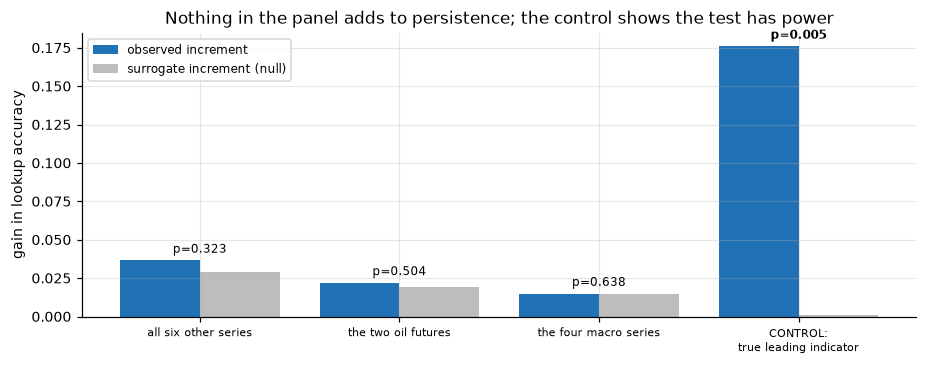

In [14]:
fig, ax = plt.subplots(figsize=(8.5, 3.4))
lab = list(inc.index); x = np.arange(len(lab))
ax.bar(x - 0.2, inc["increment"], 0.4, label="observed increment", color="#2171B5")
ax.bar(x + 0.2, inc["surrogate"], 0.4, label="surrogate increment (null)", color="#BDBDBD")
for i, p in enumerate(inc["p"]):
    ax.text(i, max(inc["increment"].iloc[i], inc["surrogate"].iloc[i]) + 0.005,
            f"p={p:.3f}", ha="center", fontsize=8,
            weight="bold" if p < 0.05 else "normal")
ax.set_xticks(x); ax.set_xticklabels([l.replace(": ", ":\n") for l in lab], fontsize=7.5)
ax.set_ylabel("gain in lookup accuracy"); ax.legend(fontsize=8)
ax.set_title("Nothing in the panel adds to persistence; the control shows the test has power")
plt.tight_layout(); plt.show()

### 9. What Gate 1.0 establishes

Read literally the gate **passes**: cross-variable structure beats its null. Read
on its stated intent it **fails**: nothing beats persistence.

The value is not the negative. It is what the negative *explains*. GWP3 recorded
two facts about its improved belief network — that it was statistically
indistinguishable from persistence (McNemar *p* = 1.00), and that its Markov
blanket collapsed to WTI\_CL alone — and treated both as properties of the fitted
model, the second as an instability to apologise for in section 7.

Both are properties of the **data**. There is no predictive content for the
one-month WTI regime in this panel beyond the regime's own persistence, for any
model over these seven variables at in-degree ≤ 3. The blanket collapsed to
WTI\_CL because WTI\_CL is the target under another name. The network tied
persistence because persistence is everything there is.

**Scope, honestly.** This tests in-degree ≤ 3 over seven ternary variables at
monthly frequency. It does not exclude structure at higher in-degree (coverage of
1.55 per cent means the sample could not support it), at longer lags, or under a
different discretisation. Those are Phase 2 and Phase 3 questions. Lookup
accuracy is an in-sample quantity, interpretable here only because every
comparison is against a surrogate computed the same way; it must never be quoted
as a forecasting accuracy.